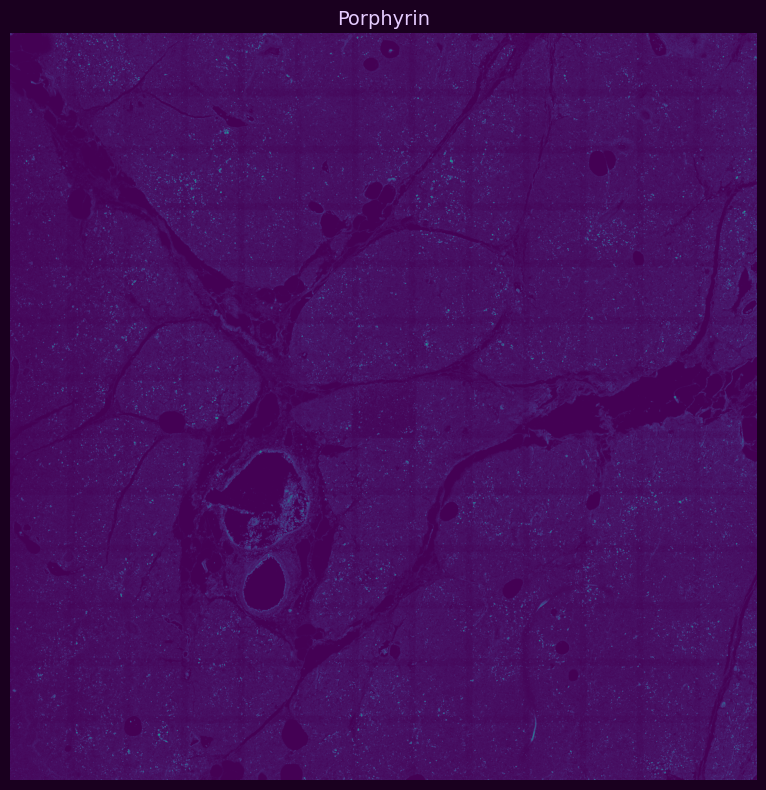

In [5]:
from pathlib import Path
import tifffile as tiff
import matplotlib.pyplot as plt


# Build image path
channels = ['SHG', 'NADH', 'FAD', 'Lipofuscin', 'Porphyrin'] # ffpe were read for 5 channels 
img_path = Path(f"dataset/37892N/Fused_Images/{channels[4]}_fused.tif")

# Load image
img = tiff.imread(img_path)

# Plot in purple theme
plt.figure(figsize=(8, 8), facecolor="#1a001f")
plt.imshow(img)#, cmap="Purples")
plt.axis("off")
plt.title(f"{channels[4]}", color="#e6ccff", fontsize=14)
plt.tight_layout()
plt.savefig(f'{channels[4]}.png')
plt.show()

In [7]:
import numpy as np
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import accuracy_score, roc_auc_score
import pandas as pd
from pathlib import Path
from PIL import Image
import mahotas
from tqdm import tqdm

data = pd.read_csv("PNET_cancer_final.csv")
names = data["names"]
classes = data["class"]
len(classes)

48

In [7]:
# classifying tumors and no tumors
y = []
for cl in classes:
    if cl == "normal":
        y.append(0)
    else:
        y.append(1)
y = np.array(y)
y.shape

(48,)

In [9]:
import numpy as np, tifffile, pandas as pd
from tqdm import tqdm
import mahotas

channels = ['SHG', 'NADH', 'FAD', 'Lipofuscin', 'Porphyrin']  
def compute_haralick_paper(gray16):
    F = gray16.astype(np.float64) + 256
    F[F > 65535] = 0
    F = (F / 65535.0 * 255.0).astype(np.uint8)
    return mahotas.features.haralick(F, ignore_zeros=True).mean(axis=0)   # 13 features

feature_names = [f"{ch}_{k:02d}" for ch in channels for k in range(13)]   # SHG_00 .. Porphyrin_12

rows = []
for name in tqdm(names):
    row = []
    for ch in channels:
        g = tifffile.imread(f"dataset/{name}/Fused_Images/{ch}_fused.tif")
        row.extend(compute_haralick_paper(g))
    rows.append(row)

# Build the dataframe 
df_features = pd.DataFrame(rows, columns=feature_names)
df_features.insert(0, "Type", ["normal" if c == "normal" else "tumor" for c in classes])
df_features.insert(0, "Sample", list(names))
print(df_features.shape)     # -> (48, 67)  == Sample + Type + 65 features


100%|██████████| 48/48 [00:47<00:00,  1.01it/s]

(48, 67)


In [11]:
df_features.head()

,Sample,Type,SHG_00,SHG_01,SHG_02,SHG_03,SHG_04,SHG_05,SHG_06,SHG_07,...,Porphyrin_03,Porphyrin_04,Porphyrin_05,Porphyrin_06,Porphyrin_07,Porphyrin_08,Porphyrin_09,Porphyrin_10,Porphyrin_11,Porphyrin_12
0,#240,tumor,0.001181,173.680993,0.751870,349.982277,0.154714,53.493422,1226.248114,6.948223,...,556.182916,0.138700,57.337832,1843.044976,7.091846,11.688096,0.000127,5.233788,-0.093800,0.825434
1,#299_83257,tumor,0.237823,171.406405,0.768355,369.976999,0.617952,19.064361,1308.501590,4.246397,...,943.870569,0.376390,45.226682,3468.491195,5.966452,9.034256,0.000437,4.350810,-0.225319,0.947892
2,#371_83502,tumor,0.082864,216.859318,0.696671,357.460074,0.490858,19.276457,1212.980979,4.988092,...,211.595394,0.286453,25.393930,700.264140,5.806601,9.116064,0.000308,4.280544,-0.124086,0.836514
3,#396_84597,tumor,0.033638,42.535730,0.731150,79.106429,0.376693,17.034424,273.889986,5.250149,...,1369.429064,0.208888,71.989295,4879.996871,7.277267,11.652925,0.000167,5.308781,-0.154926,0.925472
4,37892N,normal,0.059602,52.241313,0.735241,98.657116,0.566897,9.590978,342.387150,4.060917,...,103.745263,0.258519,22.329018,326.205037,5.471970,8.750623,0.000357,3.860687,-0.107127,0.792020


In [13]:
# Correlation filter
import statistics, numpy as np

df_corr  = df_features.drop(columns=["Type", "Sample"])
corr_mat = df_corr.corr().abs()
avg_corr = {c: statistics.mean(corr_mat[c]) for c in corr_mat.columns}   # include self-corr=1
sorted_dict = {k: avg_corr[k] for k in sorted(avg_corr, key=avg_corr.get)}
top, i, mean_threshold = [], 0, 0.45
while np.take(list(sorted_dict.values()), i) < mean_threshold:
    top.append(np.take(list(sorted_dict.keys()), i)); i += 1
LDA_features = list(top)
print(f"65 -> {len(LDA_features)} features kept (mean |corr| < 0.45)")
print(sorted(LDA_features))

65 -> 22 features kept (mean |corr| < 0.45)
['FAD_00', 'FAD_02', 'FAD_06', 'FAD_12', 'Lipofuscin_00', 'Lipofuscin_02', 'Lipofuscin_12', 'NADH_00', 'NADH_02', 'NADH_12', 'Porphyrin_01', 'Porphyrin_02', 'Porphyrin_03', 'Porphyrin_06', 'Porphyrin_11', 'Porphyrin_12', 'SHG_00', 'SHG_02', 'SHG_03', 'SHG_06', 'SHG_11', 'SHG_12']


In [15]:
import itertools, numpy as np
from random import sample
import random
from numpy import mean, zeros
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn import preprocessing

def leave_n_out_multi(X, y, n=1):
    score, real, mislabeled = [], [], [0]*len(X)
    for x in itertools.combinations(range(len(X)), len(X)-n): # out of 22 features, pick 22-n features and keep choosing all possible combinations
        X_train = X[list(x)] # pick 22-n features
        index   = [i for i in range(len(X)) if i not in x] # return index of the n features that were not chosen
        X_val, y_train, y_val = X[index], y[list(x)], y[index]
        clf = LinearDiscriminantAnalysis(solver="svd").fit(X_train, y_train) # perform lda
        s = clf.score(X_val, y_val); score.append(s) # return the score
        if s < 1: 
            mislabeled[int(index[0])] += 1  # if the prediction is wrong, add a mark to that feature
    return (score, mislabeled)

def compute_LDA_accuracy_multi(df, cl=["tumor", "normal"], features=None, seed=1, n=3):
    y = df['Type'].values # take the labels 
    enc = preprocessing.LabelEncoder().fit(y); y = enc.transform(y)  # transform labels to 0 and 1
    classes = enc.transform(cl) 
    i_array = np.array([i in classes for i in y]); y = y[i_array]
    mx, bfs, mislabeled = 0, [None], [] # max accuracy, best feature set, mislabel
    random.seed(seed)
    for _ in itertools.combinations(features, n):
        bf = random.sample(features, n)                    
        Xb = df[bf].values.astype("float")[i_array]
        S, M = leave_n_out_multi(Xb, y, n=1)
        v = mean(S)
        if v > mx: 
            mx, bfs, mislabeled = v, bf, M
    return mx, bfs, mislabeled

# ---- NUM_RUNS runs per n 
NUM_RUNS = 4    
N_MAX    = 1    

score_list = []
BF_list = []
print(f"\n n | accuracy")
print("---+---------------------------")
F = 4
for r in range(NUM_RUNS):
    v, BF, M = compute_LDA_accuracy_multi(df_features, features=LDA_features, seed=r,n=F)
    score_list.append(v)
    print(v)
    BF_list.append(BF)
    print(BF)



 n | mean accuracy (over 5 runs)
---+---------------------------
0.875
['Lipofuscin_12', 'SHG_12', 'NADH_12', 'Lipofuscin_02']
0.875
['Porphyrin_12', 'NADH_12', 'Porphyrin_11', 'SHG_12']
0.875
['SHG_12', 'NADH_12', 'Lipofuscin_12', 'FAD_02']
0.875
['Lipofuscin_12', 'NADH_12', 'Lipofuscin_00', 'SHG_12']
0.875
['Lipofuscin_00', 'SHG_12', 'Lipofuscin_12', 'NADH_12']


In [1]:
BF_list = [['Lipofuscin_12', 'SHG_12', 'NADH_12', 'Lipofuscin_02'],
 ['Porphyrin_12', 'NADH_12', 'Porphyrin_11', 'SHG_12'],
 ['SHG_12', 'NADH_12', 'Lipofuscin_12', 'FAD_02'],
 ['Lipofuscin_12', 'NADH_12', 'Lipofuscin_00', 'SHG_12']]

In [43]:
from sklearn.preprocessing import MinMaxScaler
seed = 0
from sklearn.preprocessing import StandardScaler
import pandas as pd

for BF in BF_list:
    X_selected = df_features[BF]
    X_fts = X_selected.to_numpy().reshape(-1, 1)

    # Z-score standardization
    scaler = StandardScaler()
    X_fts = scaler.fit_transform(X_fts).reshape(-1)

    # shift slightly so the minimum is positive
    X_fts = X_fts - X_fts.min() + 1e-7
    
    data = pd.DataFrame()
    data["value"] = X_fts
    data.to_csv(f"input_final_seed{seed}.csv", index=False)
    seed += 1

In [31]:
from sklearn.model_selection import LeaveOneOut
from sklearn.model_selection import KFold
from joblib import Parallel, delayed, dump, load
"""
Selecting 4  features and perfrom 48 rounds of testing
"""
kf = KFold(n_splits=48)
y = df_features['Type'].values # take the labels 
enc = preprocessing.LabelEncoder().fit(y); y = enc.transform(y)  # transform labels to 0 and 1
print(y)
cl = []
for i in y:
    cl += [i]*4
cl = np.array(cl)
len(cl)

[1 1 1 1 0 1 1 0 1 1 0 1 1 0 1 0 1 1 0 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 1 1
 1 0 1 0 1 0 1 0 1 1 1]


192

In [35]:
seed = 0
for BF in BF_list:
    X_selected = df_features[BF]
    X_fts = X_selected.to_numpy().reshape(-1)
    scaler = StandardScaler()
    X_fts = scaler.fit_transform(X_fts.reshape(-1, 1)).reshape(-1) 
    for fold_number, (train_index, test_index) in enumerate(kf.split(X_fts)):
        fold_data = {
            'X_train': X_fts[train_index],
            'X_test': X_fts[test_index],
            'y_train': cl[train_index],
            'y_test': cl[test_index]
        }
        dump(fold_data, f'LOO/fold_{fold_number}_seed{seed}.joblib')
    seed+=1